# Proyecto: Modelos de Mezclas Gaussianas y Clustering Bayesiano

## Objetivo general

El objetivo de este proyecto es estudiar modelos de mezclas gaussianas para identificar subpoblaciones latentes dentro de un conjunto de datos reales.

Los estudiantes deberán implementar y comparar:

- estimación frecuentista mediante algoritmo EM,
- inferencia bayesiana mediante Gibbs sampling,
- análisis de incertidumbre posterior,
- clustering probabilístico,
- y comparación con métodos clásicos.

El proyecto busca integrar:

- modelos latentes,
- inferencia estadística,
- aprendizaje no supervisado,
- métodos MCMC,
- y visualización de resultados.

---

# Notación

- $x_i$ representa la observación.
- $z_i$ representa la clase latente.
- $K$ representa el número de componentes.
- $\pi_k$ representa el peso del componente.
- $\mu_k$ representa la media.
- $\Sigma_k$ representa la covarianza.
- $N$ representa número de observaciones.
- $D$ representa dimensión.
- $\theta$ representa el conjunto de parámetros.

---

# 1. Motivación

En muchos problemas reales los datos no provienen de una sola población homogénea.

Frecuentemente existen grupos ocultos o subpoblaciones que generan la heterogeneidad observada.

Ejemplos:

- reclamaciones de seguros,
- perfiles de clientes,
- datos biológicos,
- grupos de pacientes,
- segmentación de mercados,
- reconocimiento de patrones.

Las mezclas gaussianas permiten modelar esta heterogeneidad de manera probabilística.

---

# 2. Modelo de mezcla gaussiana

Se asume:

$$
x_i
\sim
\sum_{k=1}^{K}
\pi_k f_k(x_i)
$$

donde:

$$
\sum_{k=1}^{K}
\pi_k = 1
$$

y:

$$
f_k(x_i)
=
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
$$

Cada componente representa una subpoblación.

---

# 3. Variables latentes

Se introduce:

$$
z_i \in \{1,\ldots,K\}
$$

donde:

$$
P(z_i = k)=\pi_k
$$

La variable $z_i$ indica el cluster al cual pertenece la observación.

---

# 4. Modelo condicional

Condicionalmente:

$$
x_i \mid z_i=k
\sim
\mathcal{N}(\mu_k,\Sigma_k)
$$

El modelo completo queda:

$$
p(z_i=k,x_i\mid\theta)
=
\pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
$$

---

# 5. Algoritmo EM

El algoritmo EM estima:

$$
\theta=(\pi,\mu,\Sigma)
$$

mediante maximización de:

$$
\ell(\theta)
=
\sum_{i=1}^{N}
\log
\left(
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
\right)
$$

---

# 6. Paso E

Se calculan responsabilidades:

$$
\gamma_{ik}
=
P(z_i=k\mid x_i,\theta)
$$

dadas por:

$$
\gamma_{ik}
=
\frac{
\pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
}{
\sum_{j=1}^{K}
\pi_j
\mathcal{N}(x_i\mid\mu_j,\Sigma_j)
}
$$

---

# 7. Paso M

Actualización de parámetros.

---

## Pesos

$$
\pi_k
=
\frac{N_k}{N}
$$

donde:

$$
N_k
=
\sum_i \gamma_{ik}
$$

---

## Medias

$$
\mu_k
=
\frac{
\sum_i
\gamma_{ik}x_i
}{
N_k
}
$$

---

## Covarianzas

$$
\Sigma_k
=
\frac{
\sum_i
\gamma_{ik}
(x_i-\mu_k)(x_i-\mu_k)^T
}{
N_k
}
$$

---

# 8. Modelo Bayesiano

Además del algoritmo EM, se implementará una versión bayesiana.

Se busca inferir:

$$
p(\pi,\mu,\Sigma,z\mid X)
$$

mediante Gibbs sampling.

---

# 9. Priors

---

## Pesos

$$
\pi \sim Dir(\alpha)
$$

---

## Medias

$$
\mu_k \sim \mathcal{N}(m_0,V_0)
$$

---

## Covarianzas

$$
\Sigma_k \sim IW(S_0,\nu_0)
$$

---

# 10. Gibbs Sampling

En cada iteración se actualizan:

1. $z$
2. $\pi$
3. $\mu$
4. $\Sigma$

---

# 11. Actualización de $z$

Para cada observación:

$$
p(z_i=k\mid x_i,\mu,\Sigma,\pi)
\propto
\pi_k
\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
$$

Normalizando:

$$
p(z_i=k\mid x_i,\mu,\Sigma,\pi)
=
\frac{
\pi_k\mathcal{N}(x_i\mid\mu_k,\Sigma_k)
}{
\sum_{j=1}^{K}
\pi_j\mathcal{N}(x_i\mid\mu_j,\Sigma_j)
}
$$

---

# 12. Actualización de $\pi$

Usando conjugación Dirichlet:

$$
p(\pi\mid z)
=
Dir(
\alpha_1+N_1,\ldots,\alpha_K+N_K
)
$$

donde:

$$
N_k
=
\sum_{i=1}^{N}
I(z_i=k)
$$

---

# 13. Actualización de $\mu$

Posterior:

$$
p(\mu_k\mid\Sigma_k,z,X)
=
\mathcal{N}(m_k,V_k)
$$

con:

$$
V_k^{-1}
=
V_0^{-1}
+
N_k\Sigma_k^{-1}
$$

y:

$$
m_k
=
V_k
(
\Sigma_k^{-1}N_k\bar{x}_k
+
V_0^{-1}m_0
)
$$

donde:

$$
\bar{x}_k
=
\frac{
\sum_i I(z_i=k)x_i
}{
N_k
}
$$

---

# 14. Actualización de $\Sigma$

Posterior:

$$
p(\Sigma_k\mid\mu_k,z,X)
=
IW(S_k,\nu_k)
$$

con:

$$
S_k
=
S_0+
\sum_i
I(z_i=k)
(x_i-\mu_k)(x_i-\mu_k)^T
$$

y:

$$
\nu_k
=
\nu_0+N_k
$$

---

# 15. Distribución Wishart

La Wishart es la generalización multivariada de la Gamma.

Densidad:

$$
Wi(\Sigma\mid S,\nu)
=
\frac{1}{Z}
|\Sigma|^{(\nu-D-1)/2}
\exp
\left(
-\frac{1}{2}
tr(\Sigma S^{-1})
\right)
$$

Propiedades:

$$
E[\Sigma]=\nu S
$$

$$
mode=(\nu-D-1)S
$$

---

# 16. Distribución Inverse Wishart

Si:

$$
\Sigma^{-1}\sim Wi(S^{-1},\nu)
$$

entonces:

$$
\Sigma\sim IW(S,\nu)
$$

Propiedades:

$$
E[\Sigma]
=
\frac{S}{\nu-D-1}
$$

$$
mode=
\frac{S}{\nu+D+1}
$$

---

# 17. Dataset sugerido

Se recomienda utilizar un dataset real.

Ejemplo:

:contentReference[oaicite:0]{index=0} dataset de seguros.

Variables sugeridas:

- total claim amount,
- charges,
- pérdidas,
- costos.

Transformación:

$$
x=\log(total\ claim\ amount)
$$

---

# 18. Visualizaciones obligatorias

Los estudiantes deberán incluir:

---

## Exploración

- histogramas,
- KDE,
- boxplots,
- pairplots.

---

## EM

- log-verosimilitud,
- densidad ajustada,
- clusters,
- componentes individuales.

---

## Bayesiano

- trazas,
- histogramas posteriores,
- autocorrelación,
- posterior predictive.

---

# 19. Diagnóstico MCMC

Deberán analizar:

- burn-in,
- mixing,
- convergencia,
- estabilidad,
- multimodalidad.

---

# 20. Label switching

Deberán estudiar:

$$
(\mu_1,\mu_2)
\leftrightarrow
(\mu_2,\mu_1)
$$

y discutir su efecto.

---

# 21. Comparación con K-means (opcional)

Como extensión pueden implementar:

:contentReference[oaicite:1]{index=1}

Si:

- prior uniforme,
- covarianzas esféricas,
- asignación dura,

entonces:

$$
z_i
=
\arg\min_k
||x_i-\mu_k||^2
$$

Esto permite comparar:

- clustering probabilístico,
- clustering determinista.

---

# 22. Evaluación

Pueden comparar:

- log-likelihood,
- AIC,
- BIC,
- estabilidad,
- interpretabilidad.

---

# 23. Objetivos específicos

Los estudiantes deberán:

1. seleccionar dataset,
2. limpiar datos,
3. análisis exploratorio,
4. implementar EM,
5. implementar Gibbs,
6. comparar métodos,
7. visualizar resultados,
8. interpretar clusters,
9. discutir hallazgos.

---

# 24. Entregables

El proyecto deberá incluir:

- notebook reproducible,
- teoría,
- implementación,
- visualizaciones,
- análisis posterior,
- discusión,
- conclusiones.

In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn. decomposition import PCA
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
plt.style.use('default')



In [2]:
import torch
import pandas as pd

# **GMM univariado**

In [3]:
mix = torch.distributions.Categorical(
    probs=torch.tensor([0.5, 0.2, 0.3])
)

# Componentes (vectorizados)
comp = torch.distributions.Normal(
    loc=torch.tensor([0.0, 2.0, -2.0]),
    scale=torch.tensor([1.0, 0.5, 0.2])
)

# Mezcla Gaussiana
gauss_mix = torch.distributions.MixtureSameFamily(
    mixture_distribution=mix,
    component_distribution=comp
)

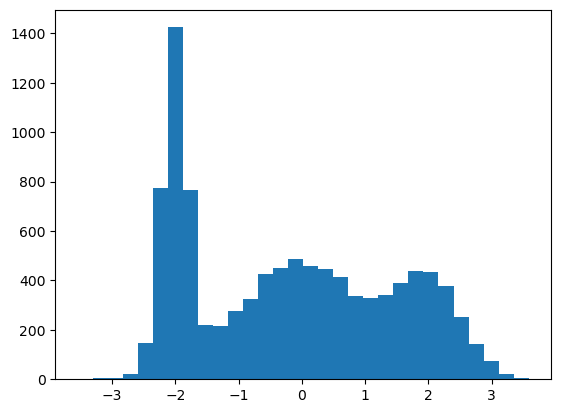

In [4]:
data  = gauss_mix.sample((10000,1))
plt.hist(data.cpu().detach().numpy(), bins=30)
plt.show()

In [5]:
class GaussianMixtureEM:
    def __init__(self, data, n_mix):
        """
        data: tensor (N,) o (N,1)
        n_mix: número de componentes
        """
        self.data = data if data.ndim == 2 else data.unsqueeze(1)
        self.N = self.data.shape[0]
        self.n_mix = n_mix

        # atributos que se llenarán al entrenar
        self.theta = None
        self.log_likelihood_history = []

    def __call__(self, tol=1e-6, max_iter=1000, seed=None):
        if seed is not None:
            torch.manual_seed(seed)

        # ----- inicialización -----
        p = torch.ones(self.n_mix) / self.n_mix
        mu = self.data[torch.randint(0, self.N, (self.n_mix,))].squeeze()
        sigma = torch.ones(self.n_mix)

        self.theta = {"p": [p], "mu": [mu], "sigma": [sigma]}
        self.log_likelihood_history = []

        ll_old = -torch.inf

        for k in range(max_iter):

            # ===== E-step =====
            dist = torch.distributions.Normal(mu, sigma)
            log_probs = dist.log_prob(self.data)           # (N,K)
            log_weighted = log_probs + torch.log(p)        # (N,K)

            log_gamma = log_weighted - torch.logsumexp(log_weighted, dim=1, keepdim=True)
            gamma = torch.exp(log_gamma)

            # ===== M-step =====
            n_k = gamma.sum(dim=0)

            p_new = n_k / self.N
            mu_new = (gamma * self.data).sum(dim=0) / n_k
            var_new = (gamma * (self.data - mu_new)**2).sum(dim=0) / n_k
            sigma_new = torch.sqrt(var_new)

            # evitar problemas numéricos
            sigma_new = torch.clamp(sigma_new, min=1e-6)
            p_new = torch.clamp(p_new, min=1e-8)
            p_new = p_new / p_new.sum()

            # ===== log-likelihood (con parámetros nuevos) =====
            dist_new = torch.distributions.Normal(mu_new, sigma_new)
            log_probs_new = dist_new.log_prob(self.data)
            log_weighted_new = log_probs_new + torch.log(p_new)

            ll = torch.logsumexp(log_weighted_new, dim=1).sum()
            self.log_likelihood_history.append(ll.item())

            print(f"Iter {k}, loglik = {ll.item():.6f}")

            # ===== criterio de paro =====
            if torch.abs(ll - ll_old) < tol:
                print("Convergió")
                break

            ll_old = ll

            # actualizar parámetros
            p, mu, sigma = p_new, mu_new, sigma_new

            # guardar historial
            self.theta["p"].append(p)
            self.theta["mu"].append(mu)
            self.theta["sigma"].append(sigma)

        return self

    def plot_log_likelihood(self):
        plt.figure()
        plt.plot(self.log_likelihood_history)
        plt.xlabel("Iteración")
        plt.ylabel("Log-verosimilitud")
        plt.title("Convergencia EM")
        plt.grid()
        plt.show()

    def plot_density(self, bins=50, show_components=True):
        """
        Grafica el histograma de los datos junto con la densidad estimada.
        """

        # últimos parámetros estimados
        p = self.theta["p"][-1]
        mu = self.theta["mu"][-1]
        sigma = self.theta["sigma"][-1]

        data = self.data.squeeze()

        # grid para evaluar densidad
        x_min, x_max = data.min().item(), data.max().item()
        x = torch.linspace(x_min, x_max, 500)

        # densidad total
        density = torch.zeros_like(x)

        for j in range(self.n_mix):
            dist = torch.distributions.Normal(mu[j], sigma[j])
            density += p[j] * torch.exp(dist.log_prob(x))

        # ===== plot =====
        plt.figure()

        # histograma
        plt.hist(data.numpy(), bins=bins, density=True, alpha=0.5)

        # mezcla total
        plt.plot(x.numpy(), density.detach().numpy(), linewidth=2, label="Mixture")

        # componentes individuales
        if show_components:
            for j in range(self.n_mix):
                dist = torch.distributions.Normal(mu[j], sigma[j])
                comp_density = p[j] * torch.exp(dist.log_prob(x))
                plt.plot(x.numpy(), comp_density.detach().numpy(), linestyle="--")

        plt.title("Ajuste de Mezcla Gaussiana (EM)")
        plt.xlabel("x")
        plt.ylabel("Densidad")
        plt.legend()
        plt.grid()

        plt.show()

In [6]:
model = GaussianMixtureEM(data, n_mix=3)
model(tol=1e-10, seed=42)


Iter 0, loglik = -17831.691406
Iter 1, loglik = -17443.496094
Iter 2, loglik = -17099.712891
Iter 3, loglik = -16789.162109
Iter 4, loglik = -16530.132812
Iter 5, loglik = -16355.022461
Iter 6, loglik = -16264.810547
Iter 7, loglik = -16227.323242
Iter 8, loglik = -16212.408203
Iter 9, loglik = -16205.836914
Iter 10, loglik = -16202.259766
Iter 11, loglik = -16199.671875
Iter 12, loglik = -16197.262695
Iter 13, loglik = -16194.656250
Iter 14, loglik = -16191.625977
Iter 15, loglik = -16187.984375
Iter 16, loglik = -16183.536133
Iter 17, loglik = -16178.043945
Iter 18, loglik = -16171.216797
Iter 19, loglik = -16162.708008
Iter 20, loglik = -16152.119141
Iter 21, loglik = -16139.052734
Iter 22, loglik = -16123.219727
Iter 23, loglik = -16104.626953
Iter 24, loglik = -16083.818359
Iter 25, loglik = -16062.004883
Iter 26, loglik = -16040.917969
Iter 27, loglik = -16022.211914
Iter 28, loglik = -16006.798828
Iter 29, loglik = -15994.603516
Iter 30, loglik = -15984.918945
Iter 31, loglik = 

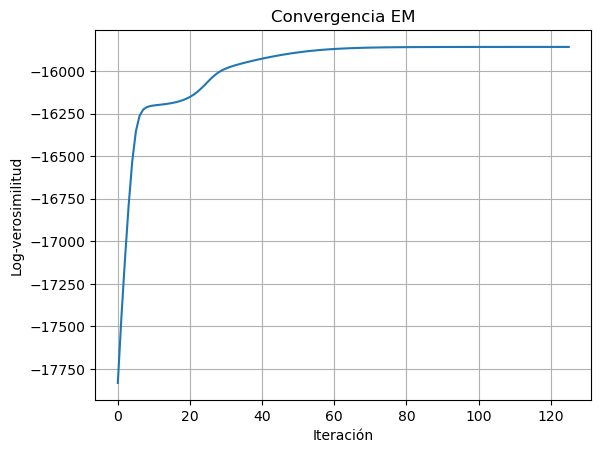

mu: tensor([-0.0132, -2.0099,  2.0220])
sigma: tensor([0.9783, 0.1973, 0.4961])
p: tensor([0.4964, 0.2976, 0.2060])


In [7]:
model.plot_log_likelihood()

# parámetros finales
print("mu:", model.theta["mu"][-1])
print("sigma:", model.theta["sigma"][-1])
print("p:", model.theta["p"][-1])

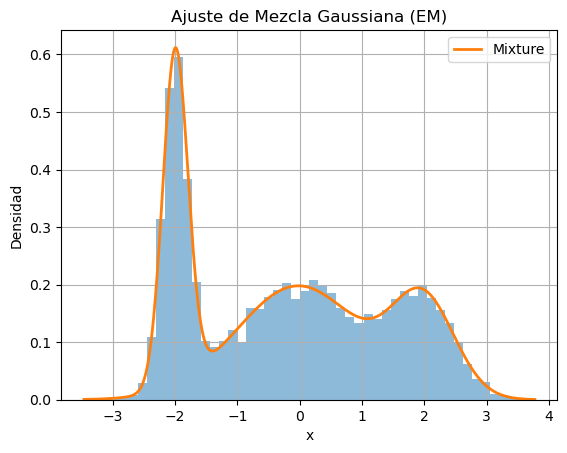

In [8]:
model.plot_density(show_components=False)

In [9]:
data_ins = pd.read_csv("data/claims_q12023.csv",sep=None, engine='python')
data_ins

,cust_age,policy_id,coverage_start_date,cust_region,sum_assured_group,ins_deductible,annual_prem,zip_code,insured_sex,edu_lvl,...,bodily_injuries,witnesses,police_report_avlbl,total_claim_amount,injury_claim,property_claim,vehicle_claim,car_brand,car_model,production_year
0,44,225016,08.09.2007,north,mid,2000,1007.48,342178,F,college,...,0,2,YES,74140,13480,13480,47180,BMW,X5,2022
1,56,316183,02.02.2016,north,mid,500,1080.60,506682,F,phd,...,2,3,NaN,56430,0,6270,50160,Honda,CRV,2021
2,28,174430,04.02.2020,east,mid,2000,1078.03,330854,M,high school,...,0,1,YES,53600,6700,6700,40200,Volkswagen,Jetta,2014
3,53,67527,27.01.2013,north,low,1000,1026.55,502272,F,college,...,0,0,NO,80960,14720,7360,58880,Accura,MDX,2007
4,47,259758,08.04.2015,east,mid,2000,1484.15,515656,F,associate,...,2,3,NaN,64100,12820,6410,44870,Dodge,RAM,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,53,477651,03.03.1998,west,low,2000,1394.54,348690,F,associate,...,2,1,NaN,47430,5270,5270,36890,Toyota,Camry,2007
996,32,265179,20.11.2013,east,high,2000,1255.11,516309,F,high school,...,1,3,NO,61270,5570,11140,44560,Subaru,Legacy,2006
997,29,182883,11.09.2013,west,low,1000,1521.28,510447,M,masters,...,1,2,YES,94560,7880,15760,70920,Jeep,Grand Cherokee,2002
998,56,438442,28.10.2009,west,mid,500,1040.67,516735,M,high school,...,0,2,NO,68040,15120,7560,45360,Subaru,Forrestor,2004


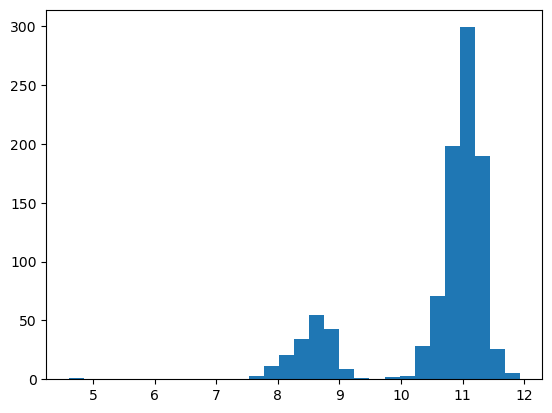

In [10]:
x = torch.tensor(data_ins["total_claim_amount"]).log()
plt.hist(x.cpu(), bins=30)
plt.show()

In [11]:
model_cm = GaussianMixtureEM(x, n_mix=2)
model_cm(tol=1e-10, seed=1997)

Iter 0, loglik = -1377.039551
Iter 1, loglik = -1209.534912
Iter 2, loglik = -858.950562
Iter 3, loglik = -767.977722
Iter 4, loglik = -746.154175
Iter 5, loglik = -736.492920
Iter 6, loglik = -729.177795
Iter 7, loglik = -721.400513
Iter 8, loglik = -711.245911
Iter 9, loglik = -698.174255
Iter 10, loglik = -684.639282
Iter 11, loglik = -675.884521
Iter 12, loglik = -673.523926
Iter 13, loglik = -673.295288
Iter 14, loglik = -673.284424
Iter 15, loglik = -673.284180
Iter 16, loglik = -673.284058
Iter 17, loglik = -673.284058
Convergió


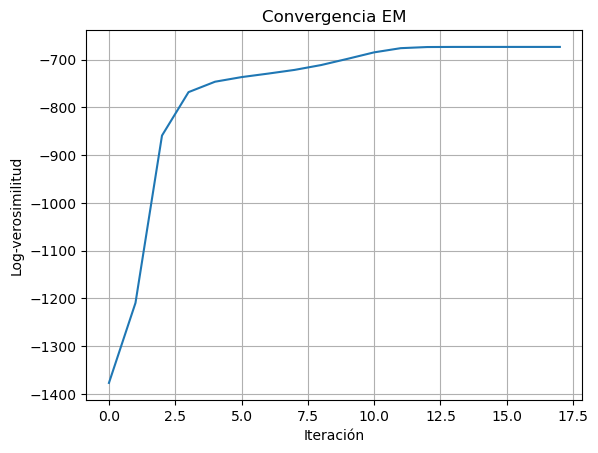

mu: tensor([ 8.5468, 11.0217])
sigma: tensor([0.4681, 0.2681])
p: tensor([0.1804, 0.8196])


In [12]:
model_cm.plot_log_likelihood()
# parámetros finales
print("mu:", model_cm.theta["mu"][-1])
print("sigma:", model_cm.theta["sigma"][-1])
print("p:", model_cm.theta["p"][-1])

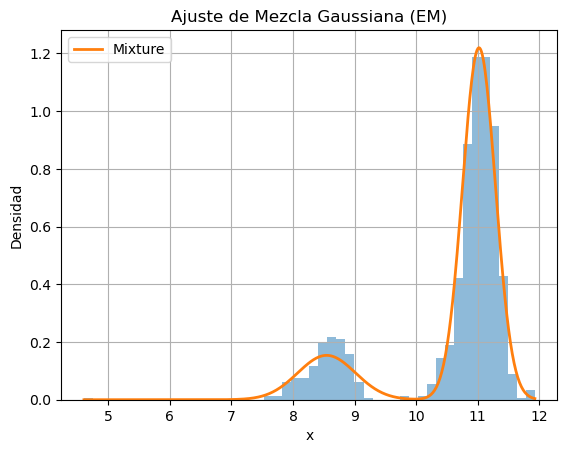

In [13]:
model_cm.plot_density(show_components=False)

# **GMM Multivariado Para Cluster**

In [14]:
class GaussianMixtureEMMultivariate:
    def __init__(self, data, n_mix):
        """
        data: tensor (N,D)
        n_mix: número de clusters
        """
        self.data = data if data.ndim == 2 else data.unsqueeze(1)
        self.N, self.D = self.data.shape
        self.K = n_mix

        self.theta = None
        self.log_likelihood_history = []
        self.gamma = None  # responsabilidades finales

    def __call__(self, tol=1e-6, max_iter=1000, seed=None):

        if seed is not None:
            torch.manual_seed(seed)

        # ===== inicialización =====
        p = torch.ones(self.K) / self.K

        # medias: (K, D)
        mu = self.data[torch.randint(0, self.N, (self.K,))]

        # covarianzas: (K, D, D)
        Sigma = torch.stack([torch.eye(self.D) for _ in range(self.K)])

        self.theta = {"p": [p], "mu": [mu], "Sigma": [Sigma]}
        self.log_likelihood_history = []

        ll_old = -torch.inf

        for it in range(max_iter):

            # ===== E-step =====
            dist = torch.distributions.MultivariateNormal(mu, Sigma)

            # (N, K)
            log_probs = dist.log_prob(self.data.unsqueeze(1))

            log_weighted = log_probs + torch.log(p)
            log_gamma = log_weighted - torch.logsumexp(log_weighted, dim=1, keepdim=True)
            gamma = torch.exp(log_gamma)

            # ===== M-step =====
            n_k = gamma.sum(dim=0)  # (K,)

            p_new = n_k / self.N

            # medias (K, D)
            mu_new = (gamma.unsqueeze(-1) * self.data.unsqueeze(1)).sum(dim=0) / n_k.unsqueeze(-1)

            # ===== covarianzas =====
            diff = self.data.unsqueeze(1) - mu_new.unsqueeze(0)  # (N, K, D)

            # producto externo → (N, K, D, D)
            outer = diff.unsqueeze(-1) * diff.unsqueeze(-2)

            # ponderación
            Sigma_new = (gamma.unsqueeze(-1).unsqueeze(-1) * outer).sum(dim=0) / n_k.view(self.K, 1, 1)

            # ===== estabilidad numérica =====
            eps = 1e-6
            eye = torch.eye(self.D, device=self.data.device).unsqueeze(0)
            Sigma_new = Sigma_new + eps * eye

            p_new = torch.clamp(p_new, min=1e-8)
            p_new = p_new / p_new.sum()

            # ===== log-likelihood =====
            dist_new = torch.distributions.MultivariateNormal(mu_new, Sigma_new)

            log_probs_new = dist_new.log_prob(self.data.unsqueeze(1))
            log_weighted_new = log_probs_new + torch.log(p_new)

            ll = torch.logsumexp(log_weighted_new, dim=1).sum()
            self.log_likelihood_history.append(ll.item())

            print(f"Iter {it}, loglik = {ll.item():.6f}")

            if torch.abs(ll - ll_old) < tol:
                print("Convergió")
                break

            ll_old = ll

            p, mu, Sigma = p_new, mu_new, Sigma_new

            self.theta["p"].append(p)
            self.theta["mu"].append(mu)
            self.theta["Sigma"].append(Sigma)

        self.gamma = gamma
        return self




    # ===== Predicciones =====
    def predict(self):
        return self.gamma.argmax(dim=1)

    def predict_proba(self):
        return self.gamma

    # ===== Visualización =====
    def plot_clusters(self):
        labels = self.predict()
        X = self.data

        if self.D == 1:
            plt.scatter(X[:, 0], torch.zeros_like(X[:, 0]), c=labels)
            plt.xlabel("x")
            plt.title("Clusters en 1D")

        elif self.D == 2:
            plt.scatter(X[:, 0], X[:, 1], c=labels)
            plt.xlabel("x1")
            plt.ylabel("x2")
            plt.title("Clusters en 2D")

        elif self.D == 3:
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
            ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels)
            ax.set_xlabel("x1")
            ax.set_ylabel("x2")
            ax.set_zlabel("x3")
            ax.set_title("Clusters en 3D")

        else:
            print("Visualización solo soporta D=1,2,3")

        plt.show()

Iter 0, loglik = -818.008545
Iter 1, loglik = -810.749878
Iter 2, loglik = -805.022156
Iter 3, loglik = -800.738647
Iter 4, loglik = -797.544556
Iter 5, loglik = -795.093140
Iter 6, loglik = -792.968323
Iter 7, loglik = -790.757935
Iter 8, loglik = -788.047546
Iter 9, loglik = -784.304871
Iter 10, loglik = -778.437439
Iter 11, loglik = -766.937988
Iter 12, loglik = -742.225708
Iter 13, loglik = -710.405884
Iter 14, loglik = -704.287720
Iter 15, loglik = -704.287170
Iter 16, loglik = -704.287170
Convergió


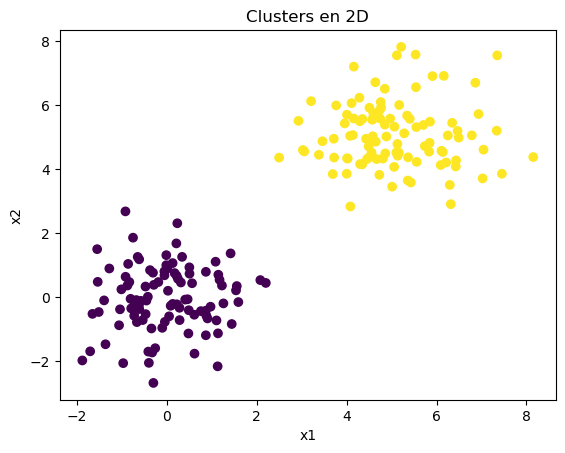

In [15]:
X1 = torch.randn(100, 2) + torch.tensor([0., 0.])
X2 = torch.randn(100, 2) + torch.tensor([5., 5.])
X = torch.cat([X1, X2], dim=0)

model = GaussianMixtureEMMultivariate(X, n_mix=2)
model()

model.plot_clusters()

In [16]:
model.predict_proba()

tensor([[1.0000e+00, 8.5510e-11],
        [1.0000e+00, 4.3916e-10],
        [1.0000e+00, 7.6091e-12],
        [1.0000e+00, 4.7463e-11],
        [1.0000e+00, 3.7645e-09],
        [1.0000e+00, 6.7041e-08],
        [1.0000e+00, 2.2589e-16],
        [1.0000e+00, 1.8532e-09],
        [1.0000e+00, 2.3496e-12],
        [1.0000e+00, 2.8344e-09],
        [1.0000e+00, 1.0520e-13],
        [1.0000e+00, 1.0680e-08],
        [1.0000e+00, 4.9899e-11],
        [1.0000e+00, 6.7474e-09],
        [1.0000e+00, 9.9500e-13],
        [1.0000e+00, 6.6040e-11],
        [1.0000e+00, 2.4480e-13],
        [1.0000e+00, 5.1420e-08],
        [1.0000e+00, 2.6552e-08],
        [1.0000e+00, 1.4533e-13],
        [1.0000e+00, 3.9370e-07],
        [1.0000e+00, 9.9135e-10],
        [1.0000e+00, 2.1386e-14],
        [1.0000e+00, 2.5403e-08],
        [1.0000e+00, 5.5016e-13],
        [1.0000e+00, 1.7002e-07],
        [1.0000e+00, 1.3826e-14],
        [1.0000e+00, 2.0537e-13],
        [1.0000e+00, 3.1183e-10],
        [9.999

In [17]:
model.theta["p"][-1]

tensor([0.5000, 0.5000])

In [18]:
model.theta["mu"][-1]

tensor([[-0.0313, -0.0401],
        [ 5.0647,  5.0668]])

In [19]:
model.theta["Sigma"][-1]

tensor([[[7.8270e-01, 6.8287e-02],
         [6.8287e-02, 9.9199e-01]],

        [[1.2149e+00, 1.1418e-03],
         [1.1418e-03, 1.0265e+00]]])

In [8]:
fifa_20 = pd.read_csv('data/players_20.csv')
features = list(fifa_20.columns[fifa_20.dtypes=='int64'])[11:]
target = ['overall']

In [9]:
scaler_X = StandardScaler()
scaler_X.fit(np.array(fifa_20[features]))

def pre_data(df, scaler_X):

    X = df[features]
    y = np.array(df[target])

    X = scaler_X.transform(X)

    return X,y

X , y = pre_data(fifa_20, scaler_X)

pca = PCA()
pca.fit(X)
CPX = pca.transform(X)

C:\Users\Academica\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


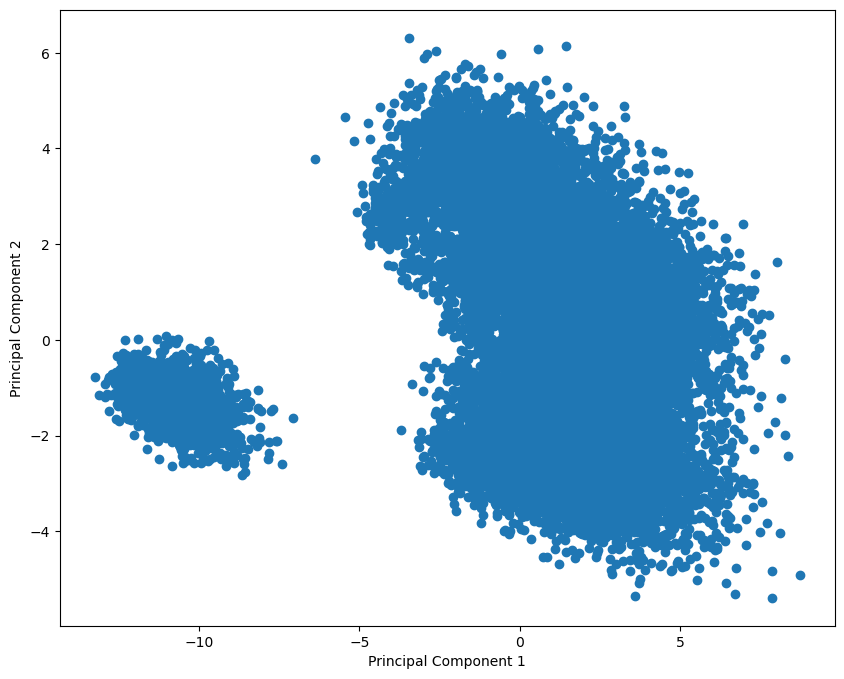

In [10]:
plt.figure(figsize=(10,8))
plt.scatter(CPX[:,0],CPX[:,1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.plot()
plt.show()

In [11]:
pca_data_fifa = torch.Tensor(CPX[:,:2])
gmm_fifa = GaussianMixtureEMMultivariate(pca_data_fifa, n_mix=2)
gmm_fifa()
gmm_fifa.plot_clusters()

NameError: name 'GaussianMixtureEMMultivariate' is not defined

In [24]:
gmm_fifa.theta["p"][-1]

tensor([0.1114, 0.8886])

In [25]:
gmm_fifa.theta["mu"][-1]

tensor([[-10.6732,  -1.2739],
        [  1.3379,   0.1597]])

In [26]:
gmm_fifa.theta["Sigma"][-1]

tensor([[[ 0.9676, -0.2045],
         [-0.2045,  0.2123]],

        [[ 4.8344, -1.8923],
         [-1.8923,  5.3551]]])

Iter 0, loglik = -84433.929688
Iter 1, loglik = -81966.210938
Iter 2, loglik = -81487.398438
Iter 3, loglik = -81017.781250
Iter 4, loglik = -80117.656250
Iter 5, loglik = -79284.492188
Iter 6, loglik = -79267.671875
Iter 7, loglik = -79254.156250
Iter 8, loglik = -79241.671875
Iter 9, loglik = -79229.906250
Iter 10, loglik = -79218.835938
Iter 11, loglik = -79208.507812
Iter 12, loglik = -79199.015625
Iter 13, loglik = -79190.421875
Iter 14, loglik = -79182.718750
Iter 15, loglik = -79175.906250
Iter 16, loglik = -79169.906250
Iter 17, loglik = -79164.640625
Iter 18, loglik = -79160.046875
Iter 19, loglik = -79156.007812
Iter 20, loglik = -79152.460938
Iter 21, loglik = -79149.335938
Iter 22, loglik = -79146.546875
Iter 23, loglik = -79144.031250
Iter 24, loglik = -79141.742188
Iter 25, loglik = -79139.640625
Iter 26, loglik = -79137.671875
Iter 27, loglik = -79135.859375
Iter 28, loglik = -79134.117188
Iter 29, loglik = -79132.468750
Iter 30, loglik = -79130.882812
Iter 31, loglik = 

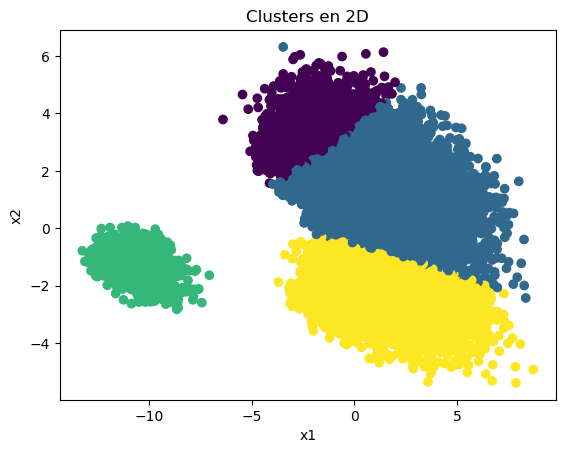

In [27]:
pca_data_fifa = torch.Tensor(CPX[:,:2])
gmm_fifa = GaussianMixtureEMMultivariate(pca_data_fifa, n_mix=4)
gmm_fifa(seed=1)
gmm_fifa.plot_clusters()

In [28]:
fifa_20['cluster'] = gmm_fifa.predict()
fifa_20[['short_name','cluster','player_positions', 'overall']].query('cluster==0')

,short_name,cluster,player_positions,overall
11,K. Koulibaly,0,CB,89
77,N. Süle,0,CB,85
83,J. Giménez,0,CB,85
90,K. Manolas,0,CB,85
156,Felipe,0,CB,84
...,...,...,...,...
18256,S. Cartwright,0,"CB, RB",48
18260,A. De Angelis,0,"CDM, CM",48
18262,S. Callan,0,"CB, RB",48
18273,Shao Shuai,0,CB,48


In [29]:
fifa_20[['short_name','cluster','player_positions', 'overall']].query('cluster==1')

,short_name,cluster,player_positions,overall
5,K. De Bruyne,1,"CAM, CM",91
7,V. van Dijk,1,CB,90
8,L. Modrić,1,CM,90
15,N. Kanté,1,"CDM, CM",89
16,G. Chiellini,1,CB,89
...,...,...,...,...
18270,M. Sagaf,1,CM,48
18271,E. Tweed,1,CM,48
18275,Zhang Wei,1,CM,48
18276,Wang Haijian,1,CM,48


In [30]:
fifa_20[['short_name','cluster','player_positions']].query('cluster==2')

,short_name,cluster,player_positions
3,J. Oblak,2,GK
6,M. ter Stegen,2,GK
13,Alisson,2,GK
14,De Gea,2,GK
25,Ederson,2,GK
...,...,...,...
18231,P. Królczyk,2,GK
18239,V. Storsve,2,GK
18251,G. Sykes-Kenworthy,2,GK
18259,H. Sveijer,2,GK


In [31]:
fifa_20[['short_name','cluster','player_positions']].query('cluster==3')

,short_name,cluster,player_positions
0,L. Messi,3,"RW, CF, ST"
1,Cristiano Ronaldo,3,"ST, LW"
2,Neymar Jr,3,"LW, CAM"
4,E. Hazard,3,"LW, CF"
9,M. Salah,3,"RW, ST"
...,...,...,...
18257,Song Min Kyu,3,LW
18258,L. Collins,3,CM
18261,H. Shirai,3,ST
18266,Wang Peng,3,CAM


# **GMM Bayesiano**

In [12]:
class BayesianGMMGibbsTorch:

    def __init__(
        self,
        K,
        n_iter=2000,
        burnin=500,
        device=None
    ):

        self.K = K
        self.n_iter = n_iter
        self.burnin = burnin

        self.device = (
            device if device is not None
            else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        )

        self.samples = None
        self.pi_ = None
        self.mu_ = None
        self.Sigma_ = None
        self.z_ = None

    def fit(self, X):

        X = torch.as_tensor(X, dtype=torch.float32, device=self.device)

        N, D = X.shape
        K = self.K

        # -----------------------
        # hiperparámetros
        # -----------------------
        alpha = torch.ones(K, device=self.device)

        m0 = X.mean(0)
        V0 = 10.0 * torch.eye(D, device=self.device)
        V0_inv = torch.inverse(V0)

        S0 = torch.eye(D, device=self.device)
        nu0 = D + 2

        # -----------------------
        # init
        # -----------------------
        z = torch.randint(0, K, (N,), device=self.device)

        pi = torch.ones(K, device=self.device) / K

        idx = torch.randperm(N, device=self.device)[:K]
        mu = X[idx].clone()

        Sigma = torch.stack([
            torch.eye(D, device=self.device)
            for _ in range(K)
        ])

        samples = {"pi": [],
                    "mu": [],
                    "Sigma": [],
                    "z":[]
                }

        for _ in range(self.n_iter):

            # =================================
            # sample z (vectorizado)
            # =================================
            log_probs = torch.empty(N, K, device=self.device)

            for k in range(K):

                mvn = torch.distributions.MultivariateNormal(
                    mu[k],
                    covariance_matrix=Sigma[k]
                )

                log_probs[:, k] = (
                    torch.log(pi[k] + 1e-12)
                    + mvn.log_prob(X)
                )

            probs = torch.softmax(log_probs, dim=1)

            # categorical sampling
            z = torch.distributions.Categorical(probs).sample()

            # =================================
            # sample pi
            # =================================
            counts = torch.bincount(z, minlength=K).float()

            #gamma_draw = torch.distributions.Gamma(
             #   alpha + counts,
              #  torch.ones_like(alpha)
            #).sample()

            pi = torch.distributions.Dirichlet(alpha + counts).sample()

            # =================================
            # sample mu
            # =================================
            sums = torch.zeros(K, D, device=self.device)
            sums.index_add_(0, z, X)

            for k in range(K):

                Nk = counts[k]

                if Nk == 0:
                    continue

                xbar = sums[k] / Nk

                Sigma_inv = torch.inverse(Sigma[k])

                Vk_inv = V0_inv + Nk * Sigma_inv
                Vk = torch.inverse(Vk_inv)

                mk = Vk @ (
                    Sigma_inv @ (Nk * xbar)
                    + V0_inv @ m0
                )

                chol = torch.linalg.cholesky(Vk)

                mu[k] = (
                    mk
                    + chol @ torch.randn(D, device=self.device)
                )

            # =================================
            # sample Sigma
            # =================================
            for k in range(K):

                Nk = counts[k]

                if Nk == 0:
                    continue

                Xk = X[z == k]

                diff = Xk - mu[k]

                scatter = diff.T @ diff

                Sk = S0 + scatter
                nuk = nu0 + Nk

                # sample Wishart and invert
                wish = torch.distributions.Wishart(
                    df=nuk,
                    precision_matrix=Sk
                ).sample()

                Sigma[k] = torch.inverse(wish)

            if _ >= self.burnin:

                samples["pi"].append(pi)
                samples["mu"].append(mu)
                samples["Sigma"].append(Sigma)
                samples["z"].append(z)

        self.samples = samples
        self.pi_ = pi
        self.mu_ = mu
        self.Sigma_ = Sigma
        self.z_ = z

        return self

In [13]:
model = BayesianGMMGibbsTorch(
    K=4,
    n_iter=4000,
    burnin=2000
)

model.fit(CPX[:, :2])

C:\Users\Academica\anaconda3\Lib\site-packages\torch\distributions\distribution.py:174: UserWarning: Singular sample detected.
  return self.rsample(sample_shape)


In [45]:
clusters = torch.stack(model.samples["z"], dim=0).mode(dim=0).values.cpu().numpy()

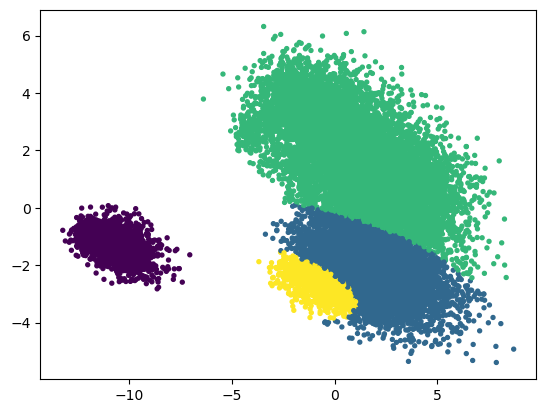

In [46]:


plt.scatter(CPX[:, 0], CPX[:, 1], c=clusters, s=8)
plt.show()

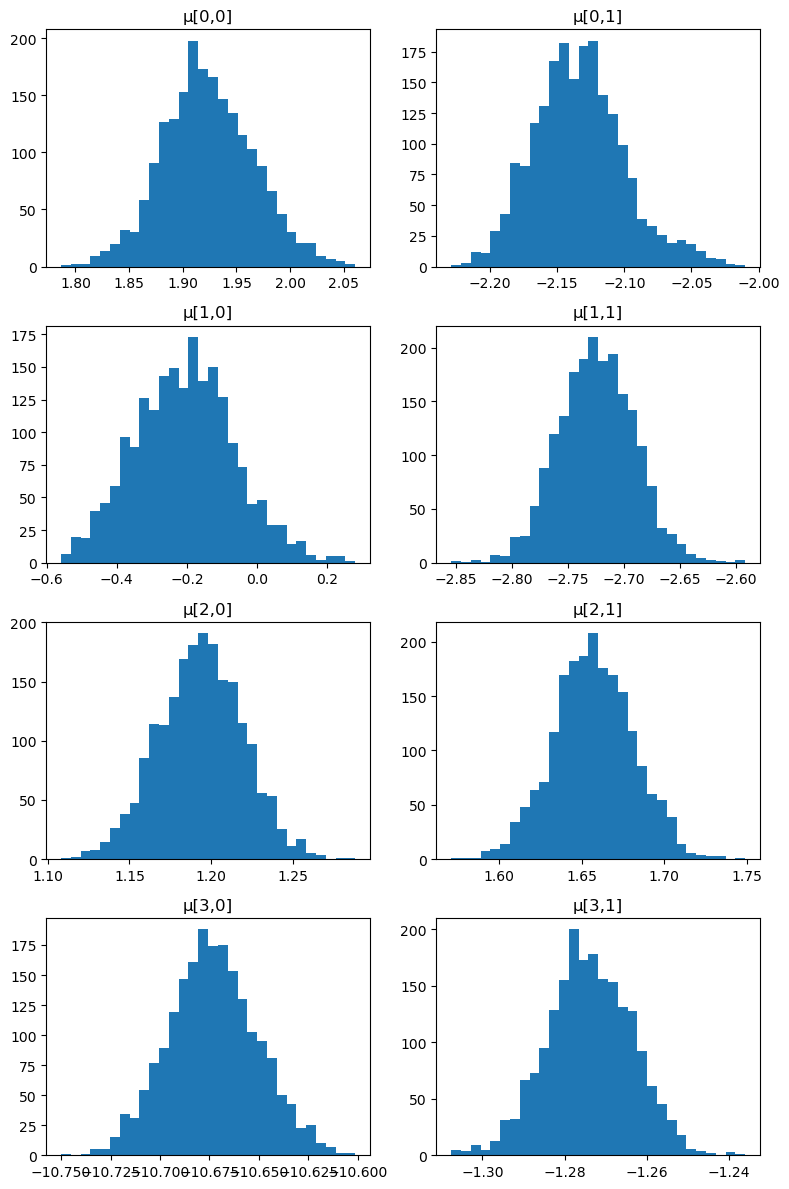

In [86]:
samples_mu = np.stack([
    s["mu"].numpy() if hasattr(s["mu"], "numpy") else s["mu"]
    for s in model.samples
])

# shape: (n_samples, K, D)

K = samples_mu.shape[1]
D = samples_mu.shape[2]

fig, axes = plt.subplots(K, D, figsize=(4*D, 3*K))

for k in range(K):
    for d in range(D):

        ax = axes[k, d] if K > 1 else axes[d]

        ax.hist(
            samples_mu[:, k, d],
            bins=30
        )

        ax.set_title(f"μ[{k},{d}]")

plt.tight_layout()
plt.show()

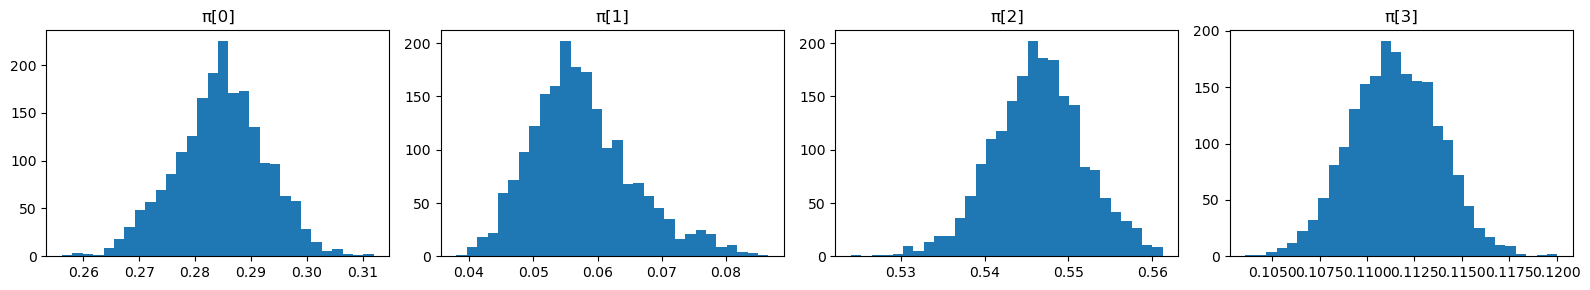

In [87]:
samples_pi = np.stack([
    s["pi"].numpy() if hasattr(s["pi"], "numpy") else s["pi"]
    for s in model.samples
])

fig, axes = plt.subplots(1, model.K, figsize=(4*model.K, 3))

for k in range(model.K):

    axes[k].hist(samples_pi[:, k], bins=30)
    axes[k].set_title(f"π[{k}]")

plt.tight_layout()
plt.show()

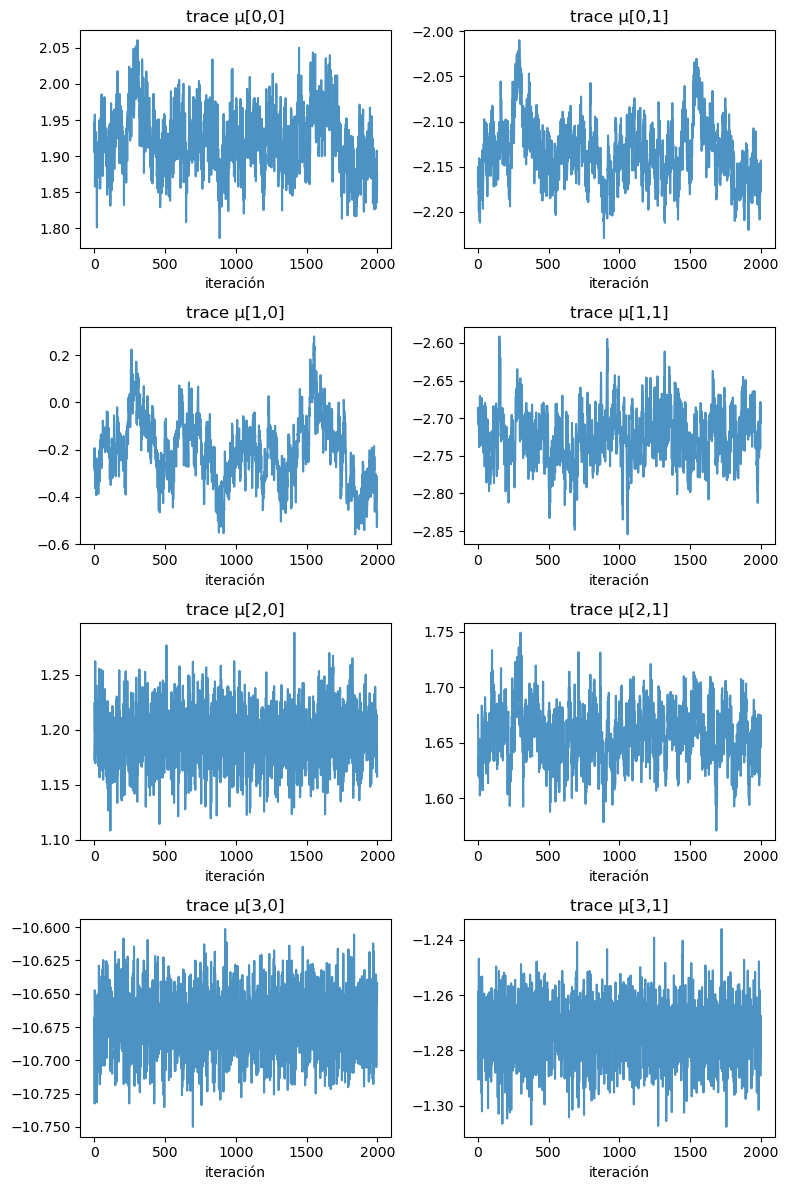

In [88]:
samples_mu = np.stack([
    s["mu"].numpy() if hasattr(s["mu"], "numpy") else s["mu"]
    for s in model.samples
])

# shape = (n_samples, K, D)

K = samples_mu.shape[1]
D = samples_mu.shape[2]

fig, axes = plt.subplots(K, D, figsize=(4*D, 3*K), squeeze=False)

for k in range(K):
    for d in range(D):
        axes[k, d].plot(samples_mu[:, k, d], alpha=0.8)
        axes[k, d].set_title(f"trace μ[{k},{d}]")
        axes[k, d].set_xlabel("iteración")

plt.tight_layout()
plt.show()

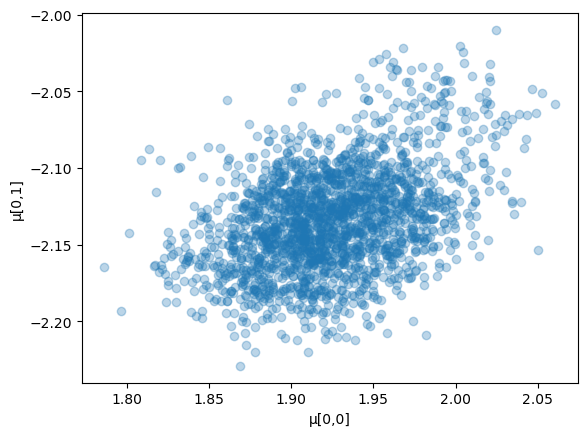

In [89]:
plt.scatter(samples_mu[:,0,0], samples_mu[:,0,1], alpha=0.3)
plt.xlabel("μ[0,0]")
plt.ylabel("μ[0,1]")
plt.show()

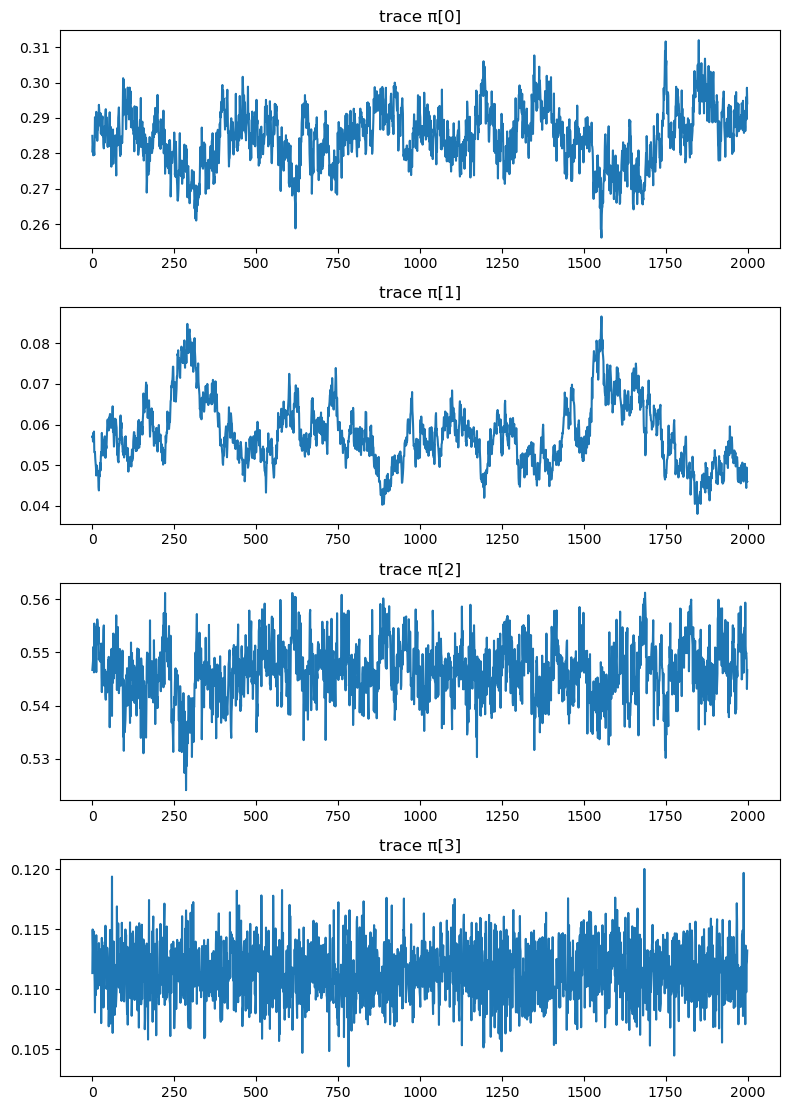

In [90]:
samples_pi = np.stack([
    s["pi"].numpy() if hasattr(s["pi"], "numpy") else s["pi"]
    for s in model.samples
])

fig, axes = plt.subplots(model.K, 1, figsize=(8, 2.8*model.K), squeeze=False)

for k in range(model.K):
    axes[k, 0].plot(samples_pi[:, k])
    axes[k, 0].set_title(f"trace π[{k}]")

plt.tight_layout()
plt.show()